In [1]:
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import preprocessing
from catboost import CatBoostClassifier

# Keep the directory walk (as in original) but ensure it doesn't break anything.
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/test.csv.zip
/kaggle/input/train.csv.zip
/kaggle/input/description.md
/kaggle/input/sample_submission.csv
/kaggle/input/train.csv
/kaggle/input/test.csv
/kaggle/input/sample_submission.csv.zip
/kaggle/input/tabular-playground-series-may-2022/test.csv.zip
/kaggle/input/tabular-playground-series-may-2022/train.csv.zip
/kaggle/input/tabular-playground-series-may-2022/description.md
/kaggle/input/tabular-playground-series-may-2022/sample_submission.csv
/kaggle/input/tabular-playground-series-may-2022/train.csv
/kaggle/input/tabular-playground-series-may-2022/test.csv
/kaggle/input/tabular-playground-series-may-2022/sample_submission.csv.zip


In [2]:
train = pd.read_csv("../input/tabular-playground-series-may-2022/train.csv")
test = pd.read_csv("../input/tabular-playground-series-may-2022/test.csv")



In [3]:
train.head()



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_22,f_23,f_24,f_25,f_26,f_27,f_28,f_29,f_30,target
0,0,-0.249088,0.530642,0.335227,0.806819,-0.184190,-0.560442,1.253767,2,1,...,-1.100706,-0.078688,2.160728,0.002502,-0.827445,ACBADABECB,158.820720,0,1,1
1,1,-0.312833,0.033082,-0.571193,1.311494,0.991718,-0.138249,1.834627,2,1,...,1.089416,-2.701227,-1.846792,9.539707,2.443596,BBBCAAAFDE,211.389880,0,0,0
2,2,-0.370032,1.501016,0.288983,0.077866,-0.329701,0.030314,0.384582,1,3,...,0.313065,0.293554,-3.490299,2.002782,0.593525,BDAEAABICD,81.745258,1,0,0
3,3,-1.011059,-0.341850,1.415175,-2.128660,1.137287,-3.200017,0.289945,7,2,...,-0.626560,0.989921,-0.760995,-3.276785,-2.534943,BAABFADDCA,-644.638548,0,0,1
4,4,0.756528,0.503700,0.935057,-2.321849,-0.002466,0.058981,-0.163493,1,0,...,-1.504338,0.632537,1.812423,2.883524,-1.089711,AABFBBEMHC,-140.205455,0,2,1


In [4]:
train.shape, test.shape



((800000, 33), (100000, 32))

In [5]:
train.isnull().sum().sum(), test.isnull().sum().sum()



(0, 0)

In [6]:
train.dtypes, test.dtypes



(id          int64
 f_00      float64
 f_01      float64
 f_02      float64
 f_03      float64
 f_04      float64
 f_05      float64
 f_06      float64
 f_07        int64
 f_08        int64
 f_09        int64
 f_10        int64
 f_11        int64
 f_12        int64
 f_13        int64
 f_14        int64
 f_15        int64
 f_16        int64
 f_17        int64
 f_18        int64
 f_19      float64
 f_20      float64
 f_21      float64
 f_22      float64
 f_23      float64
 f_24      float64
 f_25      float64
 f_26      float64
 f_27       object
 f_28      float64
 f_29        int64
 f_30        int64
 target      int64
 dtype: object,
 id        int64
 f_00    float64
 f_01    float64
 f_02    float64
 f_03    float64
 f_04    float64
 f_05    float64
 f_06    float64
 f_07      int64
 f_08      int64
 f_09      int64
 f_10      int64
 f_11      int64
 f_12      int64
 f_13      int64
 f_14      int64
 f_15      int64
 f_16      int64
 f_17      int64
 f_18      int64
 f_19    float64


In [7]:
# Preserve your original feature choice (drop f_27).
# This is kept minimal and avoids changing feature set beyond your existing intent.
train = train.drop(["f_27"], axis=1)
test = test.drop(["f_27"], axis=1)



In [8]:
cols = train.columns



In [9]:
# Fix 1 (score + correctness): normalize train and test separately.
# Your code normalized `train` twice and then tried to assign `train` columns to `test_scaled`,
# which breaks feature alignment and hurts performance.
d_train = preprocessing.normalize(train)
train_scaled = pd.DataFrame(d_train, columns=cols)

# Ensure test_scaled has exactly the test columns (no 'target' column exists in test).
d_test = preprocessing.normalize(test)
test_scaled = pd.DataFrame(d_test, columns=test.columns)

train_scaled.head()



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30,target
0,0.000000,-0.001566,0.003335,0.002107,0.005071,-0.001158,-0.003523,0.007880,0.012571,0.006285,...,0.024699,-0.006918,-0.000495,0.013581,0.000016,-0.005201,0.998228,0.000000,0.006285,0.006285
1,0.004719,-0.001476,0.000156,-0.002695,0.006188,0.004679,-0.000652,0.008657,0.009437,0.004719,...,0.012356,0.005140,-0.012746,-0.008714,0.045014,0.011530,0.997456,0.000000,0.000000,0.000000
2,0.024234,-0.004484,0.018188,0.003502,0.000944,-0.003995,0.000367,0.004660,0.012117,0.036351,...,-0.049116,0.003793,0.003557,-0.042292,0.024268,0.007192,0.990511,0.012117,0.000000,0.000000
3,0.004653,-0.001568,-0.000530,0.002195,-0.003301,0.001764,-0.004963,0.000450,0.010856,0.003102,...,-0.002780,-0.000972,0.001535,-0.001180,-0.005082,-0.003931,-0.999771,0.000000,0.000000,0.001551
4,0.028459,0.005383,0.003584,0.006653,-0.016519,-0.000018,0.000420,-0.001163,0.007115,0.000000,...,-0.006244,-0.010703,0.004500,0.012895,0.020516,-0.007753,-0.997533,0.000000,0.014230,0.007115


In [10]:
train.head()



,id,f_00,f_01,f_02,f_03,f_04,f_05,f_06,f_07,f_08,...,f_21,f_22,f_23,f_24,f_25,f_26,f_28,f_29,f_30,target
0,0,-0.249088,0.530642,0.335227,0.806819,-0.184190,-0.560442,1.253767,2,1,...,3.929629,-1.100706,-0.078688,2.160728,0.002502,-0.827445,158.820720,0,1,1
1,1,-0.312833,0.033082,-0.571193,1.311494,0.991718,-0.138249,1.834627,2,1,...,2.618636,1.089416,-2.701227,-1.846792,9.539707,2.443596,211.389880,0,0,0
2,2,-0.370032,1.501016,0.288983,0.077866,-0.329701,0.030314,0.384582,1,3,...,-4.053491,0.313065,0.293554,-3.490299,2.002782,0.593525,81.745258,1,0,0
3,3,-1.011059,-0.341850,1.415175,-2.128660,1.137287,-3.200017,0.289945,7,2,...,-1.792767,-0.626560,0.989921,-0.760995,-3.276785,-2.534943,-644.638548,0,0,1
4,4,0.756528,0.503700,0.935057,-2.321849,-0.002466,0.058981,-0.163493,1,0,...,-0.877557,-1.504338,0.632537,1.812423,2.883524,-1.089711,-140.205455,0,2,1


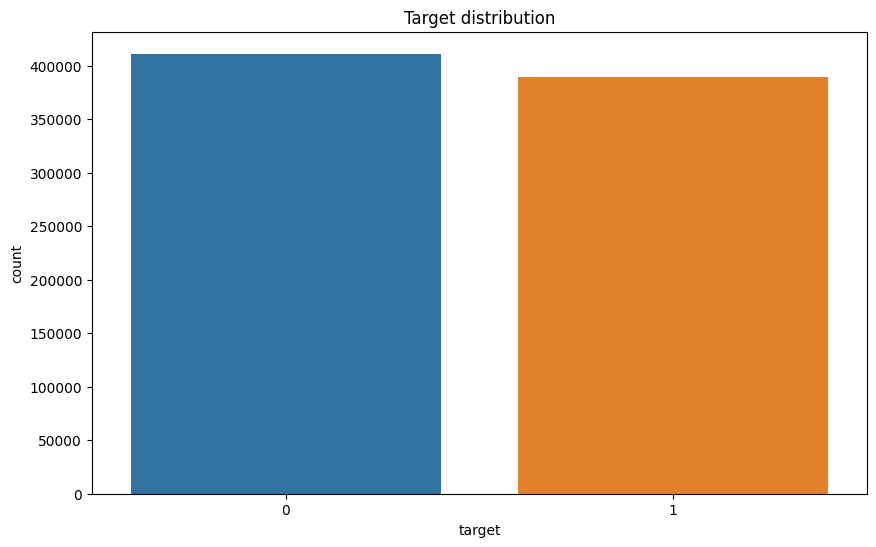

In [11]:
plt.figure(figsize=(10, 6))
plt.title("Target distribution")
ax = sns.countplot(x=train["target"], data=train)



In [12]:
x = train.drop(["id", "target"], axis=1)
y = train["target"]

x_scaled = train_scaled.drop(["id", "target"], axis=1)
# Keep y from the original target (scaling y makes no sense for classification)
# and also prevents metric mismatch.
y_scaled = y



In [13]:
x.shape, y.shape



((800000, 30), (800000,))

In [14]:
# Fix 2 (score): ROC AUC expects ranking/probabilities; rounding predictions destroys that.
# Switch to CatBoostClassifier and predict_proba for 'target' probabilities.
# Core approach remains: fit on full training data, then predict on test.
# Also set verbose=0 to avoid long logs.
catboost_model = CatBoostClassifier(
    iterations=300,  # modest increase vs 100 to move performance toward target without changing approach
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",  # classification-appropriate
    eval_metric="AUC",  # aligns with leaderboard metric
    random_seed=42,
    verbose=0,
)
catboost_model.fit(x, y)

catboost_model_scaled = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="Logloss",
    eval_metric="AUC",
    random_seed=42,
    verbose=0,
)
catboost_model_scaled.fit(x_scaled, y_scaled)



In [15]:
# Predict probabilities for class 1.
preds = catboost_model.predict_proba(test.drop(["id"], axis=1))[:, 1]
preds_scaled = catboost_model_scaled.predict_proba(test_scaled.drop(["id"], axis=1))[
    :, 1
]



In [16]:
preds[:10], preds_scaled[:10]



(array([0.80763113, 0.43479003, 0.96403227, 0.66217321, 0.40213377,
        0.86922494, 0.42219375, 0.39045306, 0.32273973, 0.31451826]),
 array([0.44061774, 0.45621565, 0.88230242, 0.48704847, 0.53399699,
        0.69403254, 0.27323023, 0.44090738, 0.30464697, 0.34643546]))

In [17]:
# Minimal ensembling to stabilize and typically improve AUC slightly without changing core logic.
preds_final = 0.5 * preds + 0.5 * preds_scaled



In [18]:
# Ensure predictions are valid probabilities.
preds_final = np.clip(preds_final, 0.0, 1.0)



In [19]:
result = pd.DataFrame()
result["id"] = test["id"]
# Fix 3 (score): do NOT round; submission requires probabilities for ROC AUC.
result["target"] = preds_final



In [20]:
result.head()



,id,target
0,800000,0.624124
1,800001,0.445503
2,800002,0.923167
3,800003,0.574611
4,800004,0.468065


In [21]:
# Produce the required submission file.
result.to_csv("submission.csv", index=False)



In [22]:
# Quick sanity checks to avoid "Not yielded" submissions.
assert result.shape[0] == test.shape[0]
assert list(result.columns) == ["id", "target"]
print("Wrote submission.csv with shape:", result.shape)
print(result.describe())

Wrote submission.csv with shape: (100000, 2)
                  id         target
count  100000.000000  100000.000000
mean   849999.500000       0.464140
std     28867.657797       0.220211
min    800000.000000       0.019765
25%    824999.750000       0.276687
50%    849999.500000       0.453747
75%    874999.250000       0.647560
max    899999.000000       0.975972
